In [1]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("../data/raw/cleaned_bank_reviews.csv")

# View first rows
df.head()

,review,rating,date,bank,source
0,wow,4,2026-05-14,CBE,Google Play
1,nice app,5,2026-05-14,CBE,Google Play
2,formative,5,2026-05-14,CBE,Google Play
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play


In [2]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
# Create sentiment scores
df['sentiment_score'] = df['review'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Classify sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(classify_sentiment)

# View results
df[['review', 'sentiment_score', 'sentiment_label']].head()

,review,sentiment_score,sentiment_label
0,wow,0.5859,Positive
1,nice app,0.4215,Positive
2,formative,0.0000,Neutral
3,best app for financial activities 🙌,0.6369,Positive
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,0.0000,Neutral


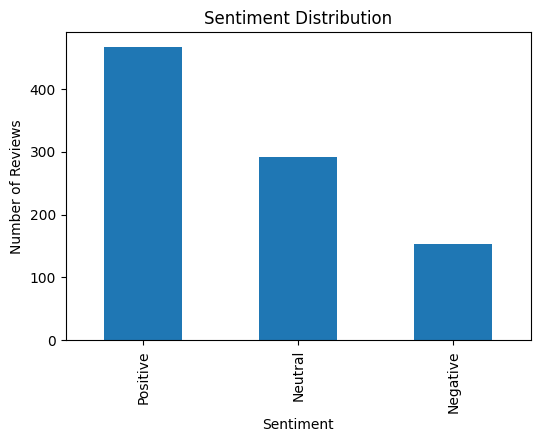

In [4]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df['sentiment_label'].value_counts()

# Plot
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/cleaned_bank_reviews.csv")

df.head()

,review,rating,date,bank,source
0,wow,4,2026-05-14,CBE,Google Play
1,nice app,5,2026-05-14,CBE,Google Play
2,formative,5,2026-05-14,CBE,Google Play
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play


In [2]:
import sys
sys.path.append("..")

from src.theme_analysis import extract_keywords

keywords = extract_keywords(df["review"])

print(keywords)

['app' 'bank' 'banking' 'best' 'dashen' 'easy' 'fast' 'fix' 'good'
 'mobile' 'mobile banking' 'nice' 'service' 'super' 'time' 'update' 'use'
 'work' 'working' 'worst']


In [1]:
import sys
sys.path.append("..")

import pandas as pd

df = pd.read_csv("../data/raw/cleaned_bank_reviews.csv")

from src.theme_analysis import extract_keywords

keywords = extract_keywords(df["review"])

print(keywords)

['app' 'bank' 'banking' 'best' 'dashen' 'fast' 'good' 'mobile' 'use'
 'working']


In [2]:
df["identified_theme"] = "General Banking Experience"

df.to_csv("../data/raw/final_sentiment_analysis.csv", index=False)

print("Final analysis saved successfully.")

Final analysis saved successfully.


## Identified Themes

### 1. Transaction Performance
Keywords:
- transfer
- slow
- payment

### 2. Account Access Issues
Keywords:
- login
- OTP
- verification

### 3. UI & User Experience
Keywords:
- interface
- easy
- design

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/cleaned_bank_reviews.csv")

df.head()

,review,rating,date,bank,source
0,wow,4,2026-05-14,CBE,Google Play
1,nice app,5,2026-05-14,CBE,Google Play
2,formative,5,2026-05-14,CBE,Google Play
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play


In [4]:
from src.sentiment import get_sentiment

df["sentiment"] = df["review"].apply(get_sentiment)

df.head()

,review,rating,date,bank,source,sentiment
0,wow,4,2026-05-14,CBE,Google Play,Positive
1,nice app,5,2026-05-14,CBE,Google Play,Positive
2,formative,5,2026-05-14,CBE,Google Play,Neutral
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,Positive
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,Neutral


In [5]:
from src.theme_analysis import extract_keywords

keywords = extract_keywords(df["review"])

print(keywords)

['app' 'bank' 'banking' 'best' 'dashen' 'fast' 'good' 'mobile' 'use'
 'working']


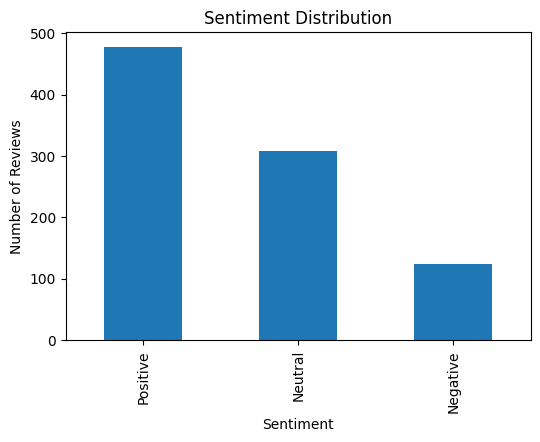

In [6]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

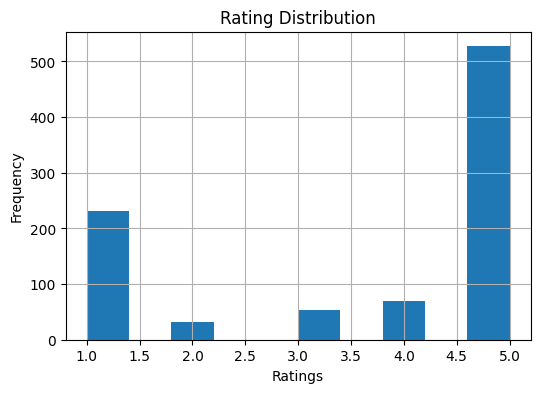

In [7]:
plt.figure(figsize=(6,4))

df["rating"].hist()

plt.title("Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Frequency")

plt.show()

In [9]:
def identify_theme(review):

    review = str(review).lower()

    if "login" in review or "password" in review or "otp" in review:
        return "Account Access Issues"

    elif "slow" in review or "transfer" in review or "loading" in review:
        return "Transaction Performance"

    elif "ui" in review or "design" in review or "interface" in review:
        return "UI & Design"

    elif "support" in review or "service" in review:
        return "Customer Support"

    else:
        return "Other"

In [10]:
df["identified_theme"] = df["review"].apply(identify_theme)

In [11]:
df.head()

,review,rating,date,bank,source,sentiment,identified_theme
0,wow,4,2026-05-14,CBE,Google Play,Positive,Other
1,nice app,5,2026-05-14,CBE,Google Play,Positive,Other
2,formative,5,2026-05-14,CBE,Google Play,Neutral,Other
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,Positive,Other
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,Neutral,Other


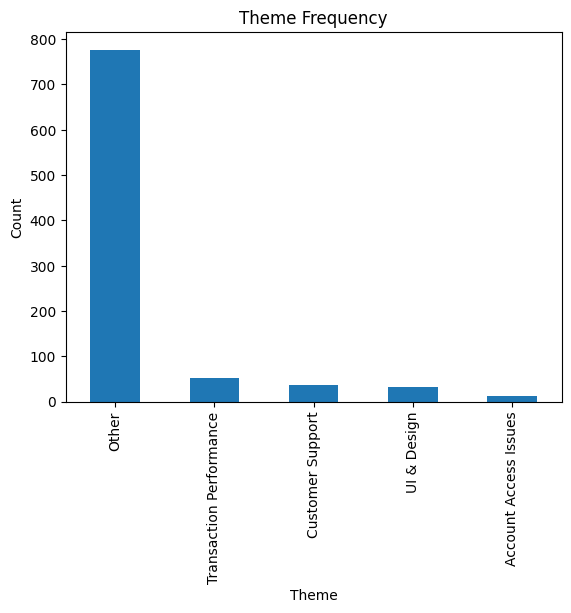

In [12]:
theme_counts = df["identified_theme"].value_counts()

theme_counts.plot(kind="bar")

plt.title("Theme Frequency")

plt.xlabel("Theme")

plt.ylabel("Count")

plt.show()

In [13]:
df.to_csv("../data/raw/analyzed_reviews.csv", index=False)